In [1]:
#!/usr/bin/env python3
"""Utility for loading a saved MODNet model."""

from __future__ import annotations

import argparse
from pathlib import Path

from modnet.models import MODNetModel
from modnet.preprocessing import MODData


DEFAULT_MODEL_PATH = (
    "/work/y-tomiya/ntu/HackNIP_master/HackNIP/"
    "benchmark_data/feat_orb2/results_modnet/best_models/"
    "random_split_dedup_w_min_freq/train2test/l11/model.modnet"
)


def load_modnet_model(model_path: str) -> MODNetModel:
    """Load and return a MODNet model from ``model_path``."""
    resolved_path = Path(model_path).expanduser().resolve()
    if not resolved_path.exists():
        raise FileNotFoundError(f"Model file not found: {resolved_path}")

    print(f"[INFO] Loading MODNet model from '{resolved_path}'.")
    model = MODNetModel.load(str(resolved_path))
    print("[INFO] Model loaded successfully.")
    return model

2025-11-21 08:07:18.422278: I tensorflow/core/util/port.cc:113] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2025-11-21 08:07:22.404792: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:9261] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2025-11-21 08:07:22.407481: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:607] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2025-11-21 08:07:22.680416: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1515] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2025-11-21 08:07:23.395489: I tensorflow/core/platform/cpu_feature_guar

In [2]:
model = load_modnet_model(DEFAULT_MODEL_PATH)

[INFO] Loading MODNet model from '/work/y-tomiya/ntu/HackNIP_master/HackNIP/benchmark_data/feat_orb2/results_modnet/best_models/random_split_dedup_w_min_freq/train2test/l11/model.modnet'.
2025-11-21 08:08:15,325 - modnet - INFO - Loaded <modnet.models.vanilla.MODNetModel object at 0x7f2098f69fa0> object, created with modnet version 0.4.5
[INFO] Model loaded successfully.


In [35]:
import gzip
import pickle

path = "/work/y-tomiya/ntu/Dataset_thermoconductivity_pred/processed_splits/dedup_w_apdb_splits/random_split_dedup_w_min_freq.pkl.gz"

with gzip.open(path, "rb") as f:
    d = pickle.load(f)

type(d), d.keys()  # どういう中身か確認

(dict,
 dict_keys(['split_type', 'X_train', 'X_test', 'y_train_log_klat', 'y_test_log_klat', 'y_train_klat', 'y_test_klat', 'train_original_indices', 'test_original_indices']))

In [36]:
d['y_test_klat']

[7.067025759123333,
 4.54501925054,
 3.041987962603,
 6.80954509626,
 41.5438009782,
 3.0664560104572334,
 3.1994033186816666,
 4.131140252445666,
 9.272989602293334,
 0.358344742756,
 42.25628176466601,
 5.278702243610001,
 43.98276296751999,
 75.92478902074,
 4.014343436134331,
 1.2391004106333332,
 8.300414436959999,
 14.234919019589034,
 8.067027735166667,
 45.24510773066666,
 10.310156276310334,
 4.776064275116668,
 1.7338761333333332,
 2.7143616411543667,
 4.7401020911866665,
 25.341409923861665,
 6.808848579972467,
 7.633573144706667,
 1.462070090767,
 5.209300528196734,
 8.112880364206667,
 1.639403136405,
 4.379542046858666,
 20.171470621986668,
 40.41571465043334,
 30.46852931220973,
 0.5857508788967332,
 8.60207075258,
 1.83952266691,
 0.6203446453344668,
 0.1929777939218,
 1.5213479664820002,
 59.01316350281466,
 71.12738910052,
 4.60815662646,
 7.202906954930667,
 3.594220454046,
 25.60477581037,
 9.47328211650867,
 0.5882017403819666,
 2.1886388294703334,
 3.7176494723430

In [3]:
path = "/work/y-tomiya/ntu/HackNIP_master/HackNIP/benchmark_data/feat_orb2/random_split_dedup_w_min_freq_test_XPS_orb2.pkl"

In [10]:
import pickle
import numpy as np
import pandas as pd

In [6]:
with open(path, "rb") as fp:
    X_test = pickle.load(fp)

In [11]:
def make_moddata(matrix: np.ndarray, targets: np.ndarray, target_name: str) -> MODData:
    """Wrap numpy arrays into MODData with consistent feature naming."""
    df = pd.DataFrame(matrix)
    series = pd.Series(targets)
    moddata = MODData(df_featurized=df, targets=series, target_names=[target_name])
    moddata.optimal_features = list(df.columns)
    return moddata

In [38]:
md_test = make_moddata(X_test['XPS_11'][:, :247], X_test['properties']['log_klat'], 'l')

In [39]:
md_test_origin = make_moddata(X_test['XPS_11'][:, :247], d['y_test_klat'], 'k')

In [13]:
test_pred = model.predict(md_test,remap_out_of_bounds=False)

43/43 [==============================] - 3s 2ms/step


In [40]:
test_pred_origin = model.predict(md_test_origin,remap_out_of_bounds=False)

43/43 [==============================] - 0s 1ms/step


In [25]:
mae = []
r2 = []
for i in test_pred.keys():
    from sklearn.metrics import mean_absolute_error, r2_score
    y_test = X_test['properties']['log_klat']
    mae.append(float(mean_absolute_error(y_test, test_pred[i])))
    r2.append(float(r2_score(y_test, test_pred[i])))
print(mae)
print(r2)
print(sum(mae)/len(mae))
print(sum(r2)/len(r2))

[0.3799431324005127, 0.38060441613197327, 0.38079634308815, 0.3801730275154114, 0.38063114881515503, 0.38074174523353577, 0.38017451763153076]
[0.7680658102035522, 0.7676181793212891, 0.7673588991165161, 0.7682186365127563, 0.7678289413452148, 0.7679593563079834, 0.7681997418403625]
0.3804377615451813
0.7678927949496678


In [41]:
mae = []
r2 = []
for i in test_pred_origin.keys():
    from sklearn.metrics import mean_absolute_error, r2_score
    y_test = d['y_test_klat']
    mae.append(float(mean_absolute_error(y_test, test_pred_origin[i])))
    r2.append(float(r2_score(y_test, test_pred_origin[i])))
print(mae)
print(r2)
print(sum(mae)/len(mae))
print(sum(r2)/len(r2))

[14.236207962036133, 14.23006820678711, 14.236227989196777, 14.233848571777344, 14.23249340057373, 14.235565185546875, 14.232864379882812]
[-0.010830163955688477, -0.010803699493408203, -0.010812044143676758, -0.010819077491760254, -0.010812997817993164, -0.0108184814453125, -0.01080930233001709]
14.23389652797154
-0.010815109525408064


In [26]:
from sklearn.metrics import mean_absolute_error, r2_score

In [81]:
y_test = X_test['properties']['log_klat']

In [27]:
float(mean_absolute_error(y_test, test_pred['g'])),float(r2_score(y_test, test_pred['g']))

(0.38079634308815, 0.7673588991165161)

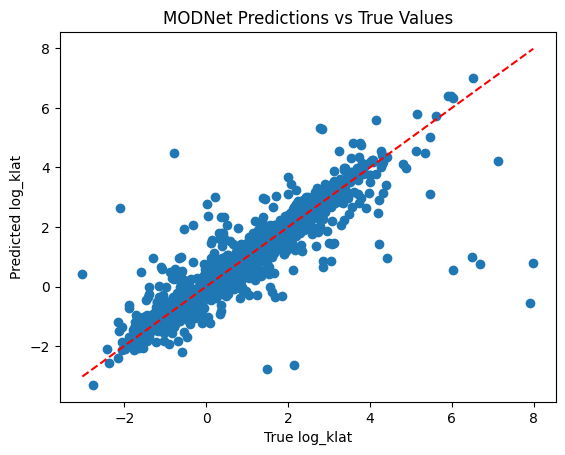

In [28]:
import matplotlib.pyplot as plt
plt.scatter(y_test, test_pred['k'])
plt.xlabel('True log_klat')
plt.ylabel('Predicted log_klat')
plt.title('MODNet Predictions vs True Values')
plt.plot([min(y_test), max(y_test)], [min(y_test), max(y_test)], color='red', linestyle='--')
plt.show()  


In [ ]:
df = pd.DataFrame({
    "y_true": y_test,
    "y_pred": test_pred["k"]
})

In [30]:
import numpy as np
from sklearn.metrics import precision_score, recall_score, f1_score

# y_true を 0 でしきい値を切って True/False ラベルに
df["y_true_bin"] = df["y_true"] >= 0   # 0以上 → True, 0未満 → False

# y_pred も同じく 0 でしきい値（符号が合っているかを見るイメージ）
df["y_pred_bin"] = df["y_pred"] >= 0

# precision / recall / f1 の計算（True を positive クラスとして計算）
precision = precision_score(df["y_true_bin"], df["y_pred_bin"], pos_label=True)
recall    = recall_score(df["y_true_bin"], df["y_pred_bin"], pos_label=True)
f1        = f1_score(df["y_true_bin"], df["y_pred_bin"], pos_label=True)

print("precision:", precision)
print("recall   :", recall)
print("f1       :", f1)

precision: 0.9488229273285568
recall   : 0.9382591093117408
f1       : 0.9435114503816794


In [32]:
mismatch_df = df[df["y_true_bin"] != df["y_pred_bin"]]

# 中身を確認
print(mismatch_df)

# 件数だけ見たい場合
print("mismatch count:", len(mismatch_df))

        y_true    y_pred  y_true_bin  y_pred_bin
49   -0.530685  0.226090       False        True
59   -0.824780  0.282002       False        True
65    0.671757 -0.079106        True       False
81    0.527937 -0.119059        True       False
94   -0.052850  0.117853       False        True
...        ...       ...         ...         ...
1292  0.355625 -0.621782        True       False
1300  0.339372 -0.939199        True       False
1314  0.368902 -0.817811        True       False
1318 -0.731450  0.353370       False        True
1322  0.506995 -0.153231        True       False

[111 rows x 4 columns]
mismatch count: 111


MAE (y>=0): 0.3806
R^2  (y>=0): 0.7678


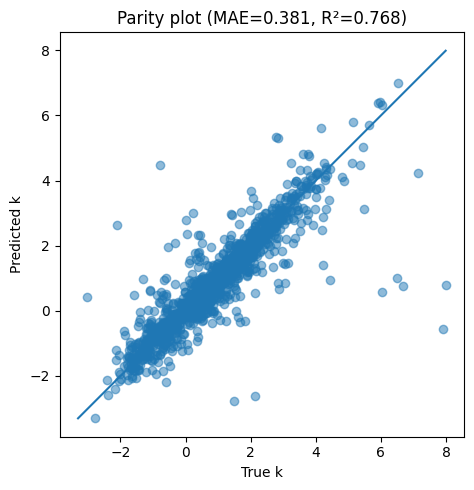

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import mean_absolute_error, r2_score

# y_test と test_pred['k'] をまとめる
df = pd.DataFrame({
    "y_true": y_test,
    "y_pred": test_pred["k"]
})

# y_test >= 0 だけにフィルタ
df_pos = df

# MAE, R^2 計算
mae = mean_absolute_error(df_pos["y_true"], df_pos["y_pred"])
r2  = r2_score(df_pos["y_true"], df_pos["y_pred"])
print(f"MAE (y>=0): {mae:.4f}")
print(f"R^2  (y>=0): {r2:.4f}")

# yy-plot（parity plot）
plt.figure(figsize=(5, 5))
plt.scatter(df_pos["y_true"], df_pos["y_pred"], alpha=0.5)

# y=x の線
min_val = min(df_pos["y_true"].min(), df_pos["y_pred"].min())
max_val = max(df_pos["y_true"].max(), df_pos["y_pred"].max())
plt.plot([min_val, max_val], [min_val, max_val])

plt.xlabel("True k")
plt.ylabel("Predicted k")
plt.title(f"Parity plot (MAE={mae:.3f}, R²={r2:.3f})")
plt.gca().set_aspect("equal", "box")
plt.tight_layout()
plt.show()

MAE (y>=0): 0.3939
R^2  (y>=0): -0.4359


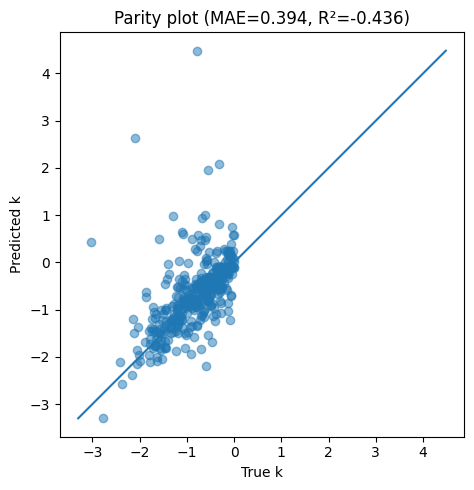

In [97]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import mean_absolute_error, r2_score

# y_test と test_pred['k'] をまとめる
df = pd.DataFrame({
    "y_true": y_test,
    "y_pred": test_pred["k"]
})

# y_test >= 0 だけにフィルタ
df_pos = df[df["y_true"] < 0]

# MAE, R^2 計算
mae = mean_absolute_error(df_pos["y_true"], df_pos["y_pred"])
r2  = r2_score(df_pos["y_true"], df_pos["y_pred"])
print(f"MAE (y>=0): {mae:.4f}")
print(f"R^2  (y>=0): {r2:.4f}")

# yy-plot（parity plot）
plt.figure(figsize=(5, 5))
plt.scatter(df_pos["y_true"], df_pos["y_pred"], alpha=0.5)

# y=x の線
min_val = min(df_pos["y_true"].min(), df_pos["y_pred"].min())
max_val = max(df_pos["y_true"].max(), df_pos["y_pred"].max())
plt.plot([min_val, max_val], [min_val, max_val])

plt.xlabel("True k")
plt.ylabel("Predicted k")
plt.title(f"Parity plot (MAE={mae:.3f}, R²={r2:.3f})")
plt.gca().set_aspect("equal", "box")
plt.tight_layout()
plt.show()

MAE (y>=0): 14.2325
R^2  (y>=0): -0.0108


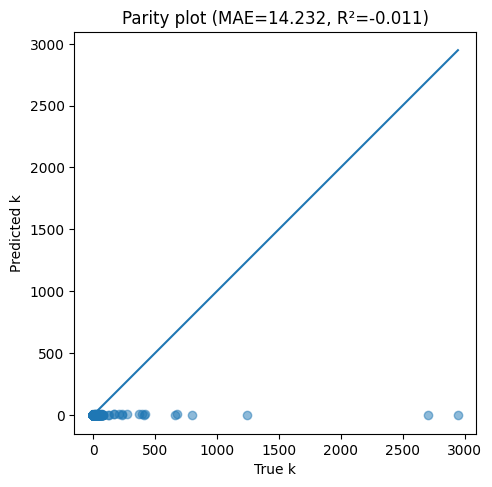

In [42]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import mean_absolute_error, r2_score

# y_test と test_pred['k'] をまとめる
df = pd.DataFrame({
    "y_true": d['y_test_klat'],
    "y_pred": test_pred_origin["k"]
})

# y_test >= 0 だけにフィルタ
df_pos = df

# MAE, R^2 計算
mae = mean_absolute_error(df_pos["y_true"], df_pos["y_pred"])
r2  = r2_score(df_pos["y_true"], df_pos["y_pred"])
print(f"MAE (y>=0): {mae:.4f}")
print(f"R^2  (y>=0): {r2:.4f}")

# yy-plot（parity plot）
plt.figure(figsize=(5, 5))
plt.scatter(df_pos["y_true"], df_pos["y_pred"], alpha=0.5)

# y=x の線
min_val = min(df_pos["y_true"].min(), df_pos["y_pred"].min())
max_val = max(df_pos["y_true"].max(), df_pos["y_pred"].max())
plt.plot([min_val, max_val], [min_val, max_val])

plt.xlabel("True k")
plt.ylabel("Predicted k")
plt.title(f"Parity plot (MAE={mae:.3f}, R²={r2:.3f})")
plt.gca().set_aspect("equal", "box")
plt.tight_layout()
plt.show()

MAE (y>=0): 2.1677
R^2  (y>=0): -0.2769


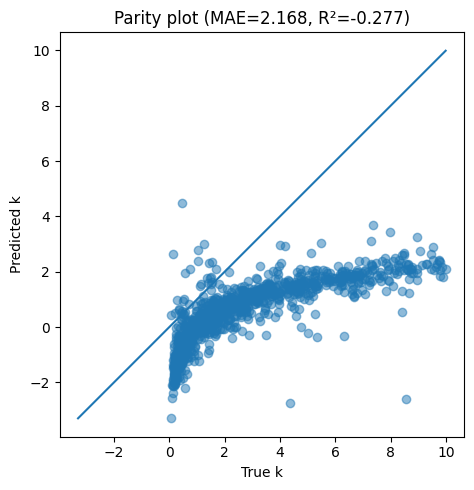

In [45]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import mean_absolute_error, r2_score

# y_test と test_pred['k'] をまとめる
df = pd.DataFrame({
    "y_true": d['y_test_klat'],
    "y_pred": test_pred_origin["k"]
})

# y_test >= 0 だけにフィルタ
df_pos = df[df["y_true"] < 10]

# MAE, R^2 計算
mae = mean_absolute_error(df_pos["y_true"], df_pos["y_pred"])
r2  = r2_score(df_pos["y_true"], df_pos["y_pred"])
print(f"MAE (y>=0): {mae:.4f}")
print(f"R^2  (y>=0): {r2:.4f}")

# yy-plot（parity plot）
plt.figure(figsize=(5, 5))
plt.scatter(df_pos["y_true"], df_pos["y_pred"], alpha=0.5)

# y=x の線
min_val = min(df_pos["y_true"].min(), df_pos["y_pred"].min())
max_val = max(df_pos["y_true"].max(), df_pos["y_pred"].max())
plt.plot([min_val, max_val], [min_val, max_val])

plt.xlabel("True k")
plt.ylabel("Predicted k")
plt.title(f"Parity plot (MAE={mae:.3f}, R²={r2:.3f})")
plt.gca().set_aspect("equal", "box")
plt.tight_layout()
plt.show()

In [46]:
df

,y_true,y_pred
0,7.067026,1.750434
1,4.545019,1.445735
2,3.041988,0.822899
3,6.809545,1.892644
4,41.543801,4.335641
...,...,...
1342,4.901679,1.645792
1343,2.139757,0.831274
1344,66.048952,2.482998
1345,2.776696,1.206583


In [47]:
import numpy as np
from sklearn.metrics import precision_score, recall_score, f1_score

# y_true を 0 でしきい値を切って True/False ラベルに
df["y_true_bin"] = df["y_true"] >= 0   # 0以上 → True, 0未満 → False

# y_pred も同じく 0 でしきい値（符号が合っているかを見るイメージ）
df["y_pred_bin"] = df["y_pred"] >= 0

# precision / recall / f1 の計算（True を positive クラスとして計算）
precision = precision_score(df["y_true_bin"], df["y_pred_bin"], pos_label=True)
recall    = recall_score(df["y_true_bin"], df["y_pred_bin"], pos_label=True)
f1        = f1_score(df["y_true_bin"], df["y_pred_bin"], pos_label=True)

print("precision:", precision)
print("recall   :", recall)
print("f1       :", f1)

precision: 1.0
recall   : 0.7253155159613957
f1       : 0.8407917383820999
